The data are from HS


c:\Users\mm66a\shared\ML\supervised-learning\notebooks
✅ Data loaded successfully!

   Temperature  Energy_kWh
0    27.490802    5.100803
1    39.014286    7.836454
2    34.639879    9.080335
3    31.973170    8.207756
4    23.120373    3.679767

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  1000 non-null   float64
 1   Energy_kWh   1000 non-null   float64
dtypes: float64(2)
memory usage: 15.8 KB
None

Missing values per column:
Temperature    0
Energy_kWh     0
dtype: int64


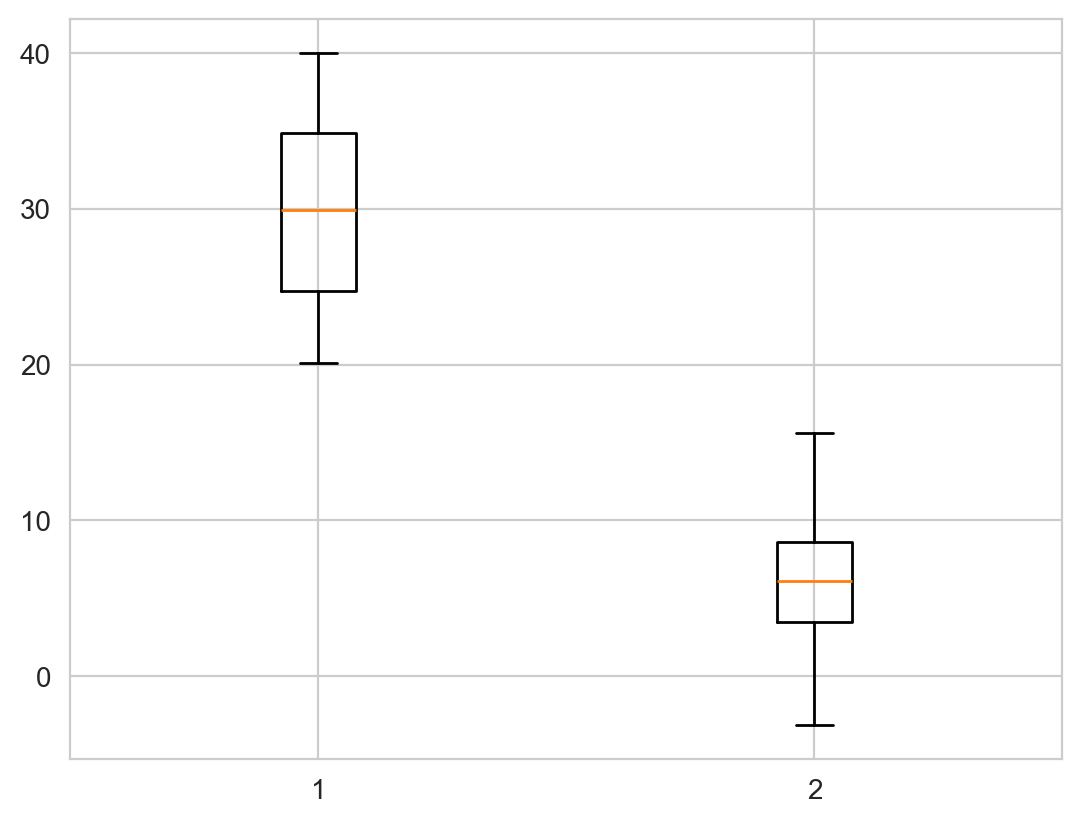

Outliers:      Temperature  Energy_kWh
0            NaN         NaN
1            NaN         NaN
2            NaN         NaN
3            NaN         NaN
4            NaN         NaN
..           ...         ...
995          NaN         NaN
996          NaN         NaN
997          NaN         NaN
998          NaN         NaN
999          NaN         NaN

[1000 rows x 2 columns]


In [4]:

# 0️⃣ Setup
import os
import sys

print(os.getcwd())
%config InlineBackend.figure_format = 'retina'
import warnings
warnings.filterwarnings("ignore")

# Add parent directory to path Zto import regression_scripts
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

# Reload module to pick up new functions
import importlib
if 'regression_scripts.regression_utils' in sys.modules:
    importlib.reload(sys.modules['regression_scripts.regression_utils'])

from regression_scripts.regression_utils import*


# -----------------------------
# 1️⃣ Load data
# -----------------------------
file_path = "../data/data_summer.csv"

if not os.path.exists(file_path):
    raise FileNotFoundError(f"CSV file not found at {file_path}")
data = pd.read_csv(file_path, sep=",")
print("✅ Data loaded successfully!\n")
print(data.head())
print("\nData info:")
print(data.info())
print("\nMissing values per column:")
print(data.isna().sum())


Q1 = np.percentile(data, 25)
Q3 = np.percentile(data, 75)
IQR = Q3 - Q1
plt.boxplot(data)
plt.show()
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

outliers = data[(data < lower_bound) | (data > upper_bound)]
print("Outliers:", outliers)  


We explore our data trying to find the relation between the  consumption of energy and the temperature

Description
       Temperature   Energy_kWh
count  1000.000000  1000.000000
mean     29.805131     6.100357
std       5.842747     3.452242
min      20.092640    -3.124562
25%      24.719465     3.493501
50%      29.936148     6.133755
75%      34.886392     8.624182
max      39.994353    15.640282


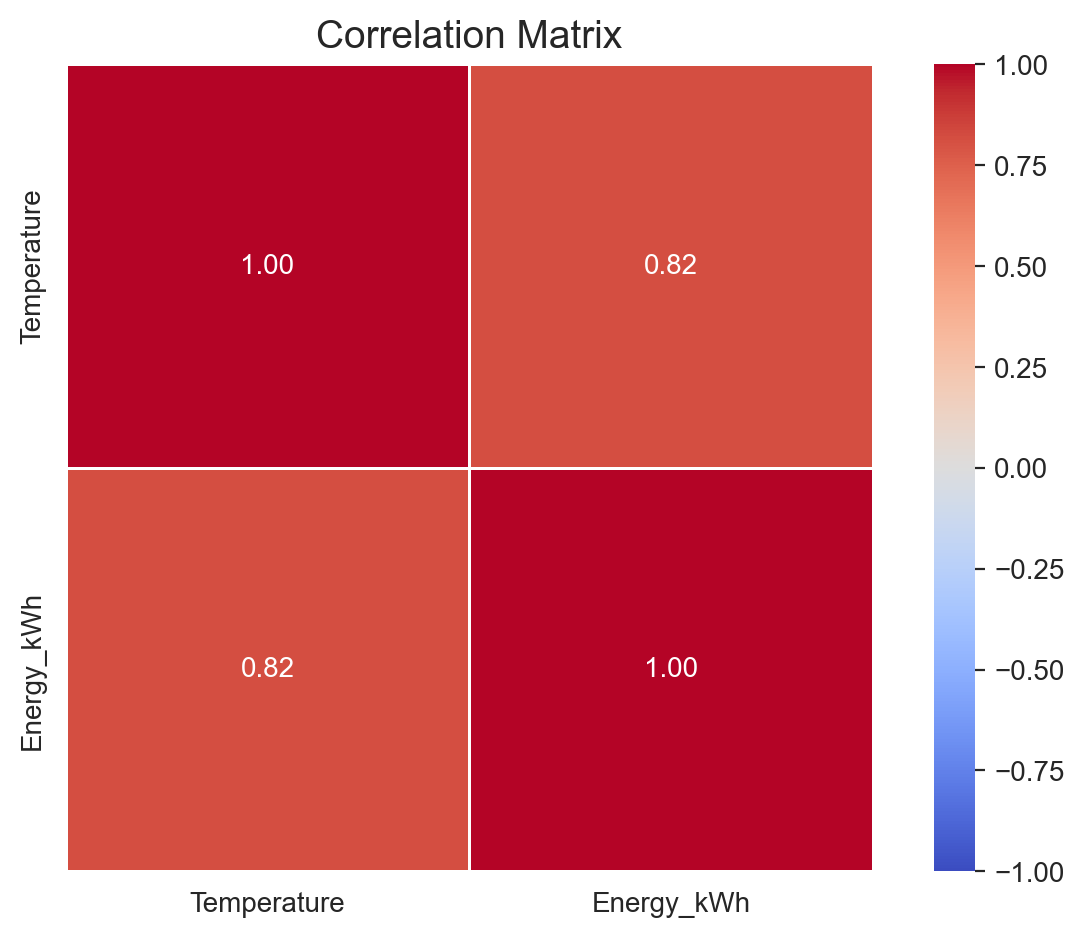

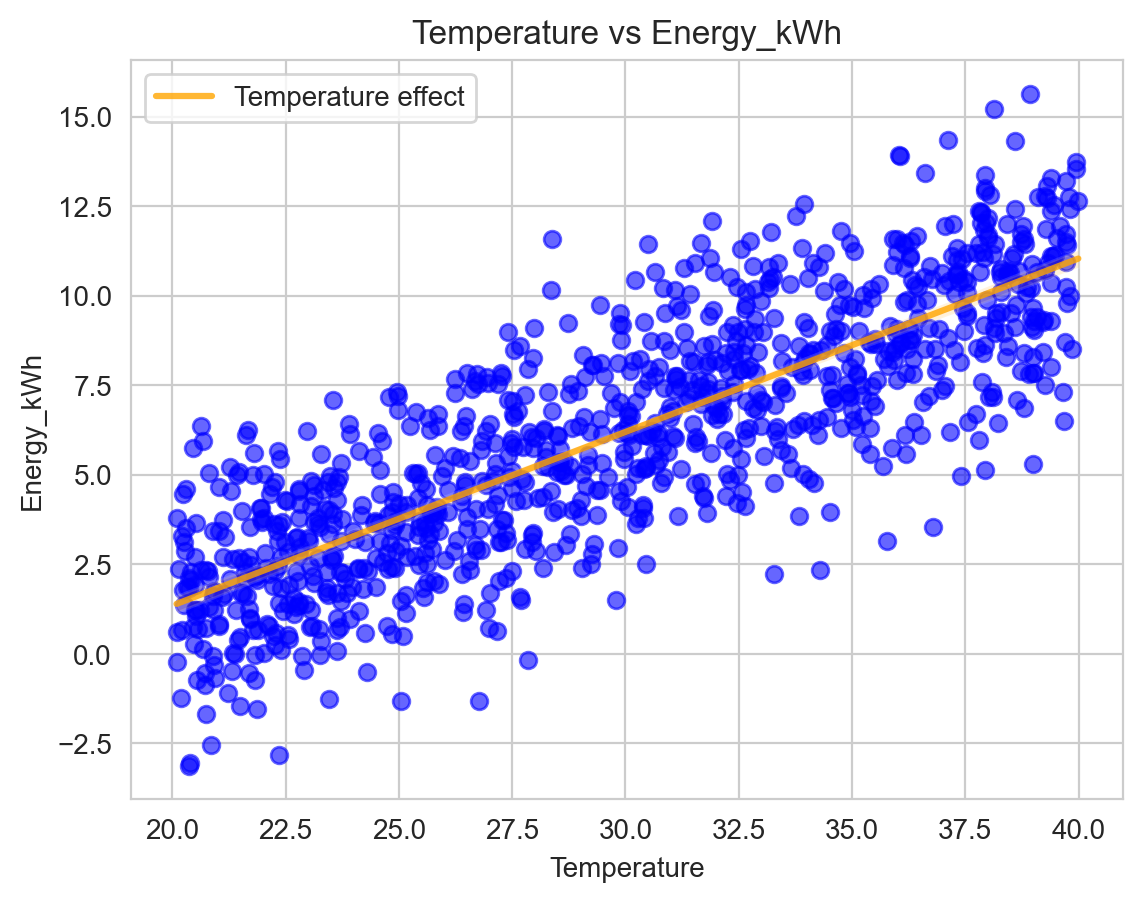

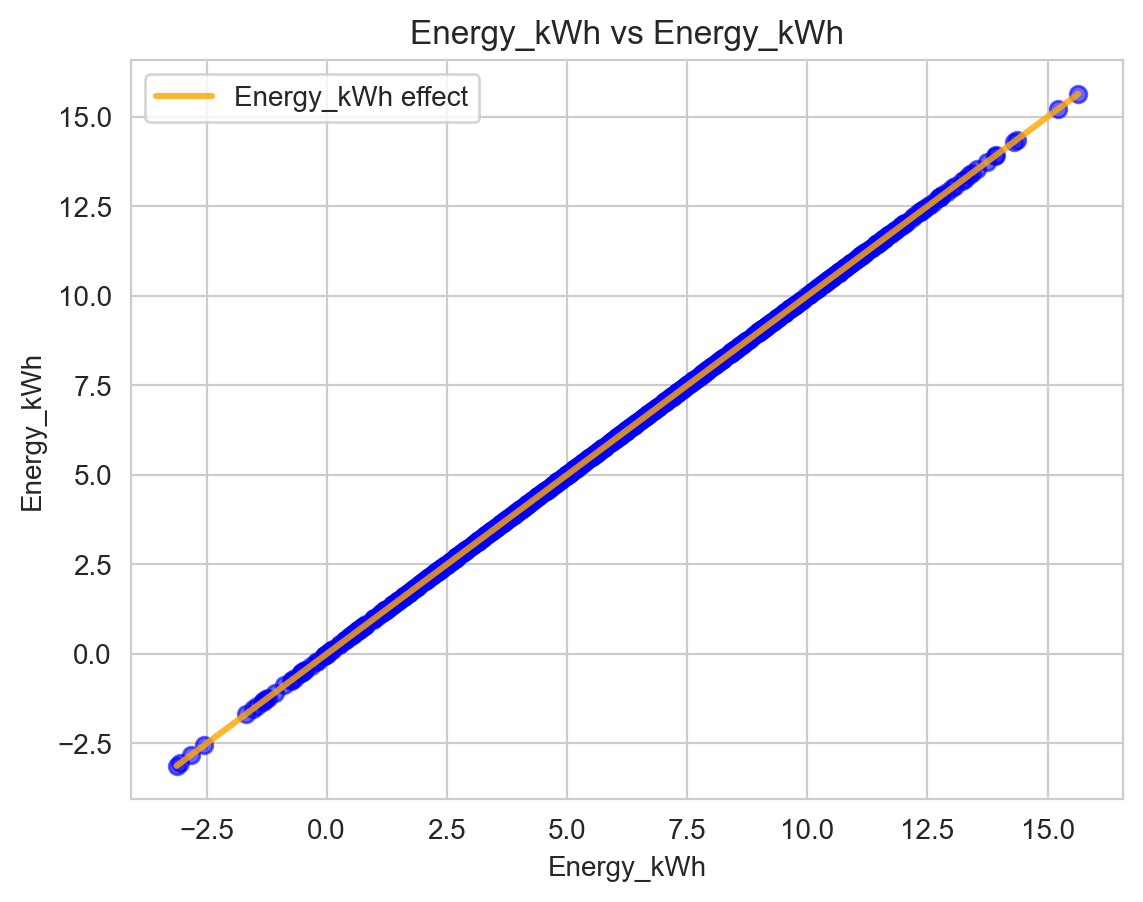

In [5]:
explore_data(data,"Energy_kWh")

In [6]:
X,y=data_process(data,"Energy_kWh") 

In [7]:
#X_train, X_val, X_test, Y_train, Y_val, Y_test
X_train, X_val,X_test,Y_train,Y_val,Y_test=split_data(X,y)

In [8]:
X_test

,Temperature
557,20.575654
798,33.933016
977,21.028516
136,30.375812
575,38.990412
...,...
731,36.291494
445,38.944972
292,36.452011
947,38.000373


✅ Regression Tree trained with max_depth=2
Test MSE: 3.81, R^2: 0.67


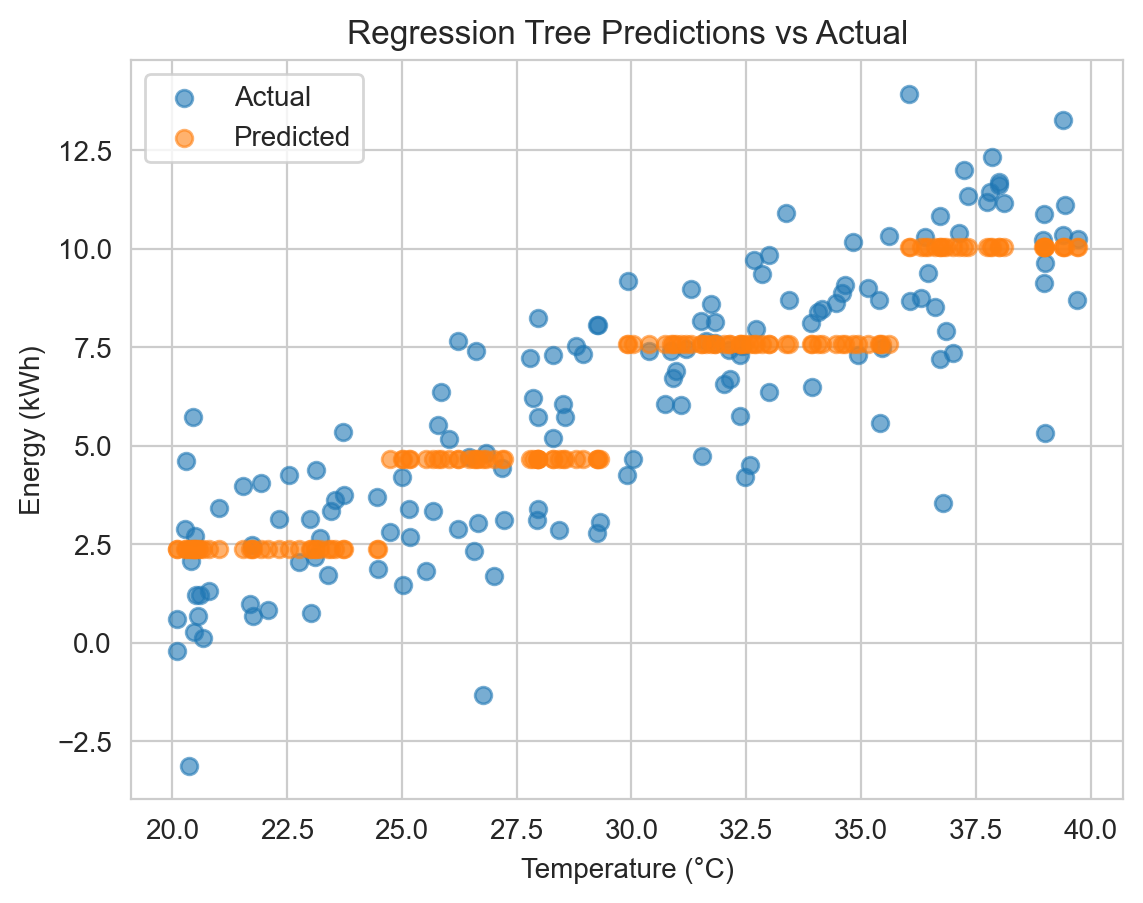

In [9]:

tree_model = train_regression_tree(X_train, Y_train, max_depth=2
                                  )

# Make predictions on test set
Y_pred = tree_model.predict(X_test)

# Evaluate
mse = mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

print(f"Test MSE: {mse:.2f}, R^2: {r2:.2f}")

# Optional: visualize predicted vs actual
plt.scatter(X_test, Y_test, label='Actual', alpha=0.6)
plt.scatter(X_test, Y_pred, label='Predicted', alpha=0.6)
plt.xlabel('Temperature (°C)')
plt.ylabel('Energy (kWh)')
plt.title('Regression Tree Predictions vs Actual')
plt.legend()
plt.show()



In [10]:
data

,Temperature,Energy_kWh
0,27.490802,5.100803
1,39.014286,7.836454
2,34.639879,9.080335
3,31.973170,8.207756
4,23.120373,3.679767
...,...,...
995,21.831641,-0.724224
996,38.346272,8.949598
997,22.736373,2.294113
998,39.004747,9.643769


In [11]:
from sklearn.tree import export_text

tree_rules = export_text(tree_model, feature_names=list(X_train.columns))
print(tree_rules)


|--- Temperature <= 29.44
|   |--- Temperature <= 24.51
|   |   |--- value: [2.38]
|   |--- Temperature >  24.51
|   |   |--- value: [4.67]
|--- Temperature >  29.44
|   |--- Temperature <= 35.89
|   |   |--- value: [7.58]
|   |--- Temperature >  35.89
|   |   |--- value: [10.05]



Decision Tree Regression: Motor response based on Temperature

                 [Temperature]
                   /       \
       Temp <= 29.44       Temp > 29.44
          /      \            /       \
 Temp <= 24.51  Temp > 24.51  Temp <= 35.89  Temp > 35.89
      |              |             |             |
   2.38 (light)   4.67 (moderate) 7.58 (high)  10.05 (critical)

Legend:
- Light: motor running lightly, low load
- Moderate: motor running moderate load
- High: motor running high load, needs monitoring
- Critical: motor at critical load, risk of overheating, take action

Leaf values are averages of measured motor load in each temperature range.